# 04 - Relatório

Notebook principal com a narrativa da pesquisa: reúne os achados dos
notebooks anteriores em uma análise contada com texto, gráficos e
conclusões. Serve de base para `docs/relatorio.md`.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from src.risco import resumo_anual_risco, contar_sequencias_secas

clima = pd.read_csv("../data/processed/lavras_clima_limpo.csv")
clima["time"] = pd.to_datetime(clima["time"])

geada_estacao = pd.read_csv("../data/processed/lavras_geada_estacao_83687_limpo.csv")
geada_estacao["time"] = pd.to_datetime(geada_estacao["time"])
clima = clima.merge(geada_estacao[["time", "tmin_estacao"]], on="time", how="left")

producao = pd.read_csv("../data/processed/lavras_producao_cafe_limpo.csv").set_index("ano")

resumo = resumo_anual_risco(clima, tmin_geada=clima["tmin_estacao"])
veranicos = contar_sequencias_secas(clima)
clima_x_producao = resumo.join(producao, how="inner")

clima.shape, producao.shape


((9132, 5), (25, 3))

## Dados

- **Clima**: Open-Meteo (reanálise histórica), diário, 2000-2024, Lavras-MG — temperatura máxima/mínima e precipitação.
- **Geada**: temperatura mínima observada na estação real do INMET em Lavras/UFLA (código 83687), extraída dos dados de observação por estação usados para construir o BR-DWGD (Xavier et al., 2022) — usada só para o índice de geada; as demais variáveis seguem do Open-Meteo.
- **Produção cafeeira**: IBGE/SIDRA (PAM, tabela 1613), anual, 2000-2024, nível municipal — área colhida, quantidade produzida e rendimento médio.

As séries cobrem os mesmos 25 anos e passaram por checagem de
valores faltantes, duplicatas e consistência lógica em `02_limpeza.ipynb`
— nenhum problema foi encontrado.


## Achado 1 — Geada: resolvemos a fonte, mas ela foi rara nesses 25 anos

Com o Open-Meteo (reanálise em grade), nenhum dia da série de 25 anos era
classificado como geada — limitação de fonte, não evidência de ausência
de geada em Lavras (decisão original registrada em `03_eda.ipynb`).
Tentamos destravar isso via BDMEP (pedido de exportação sem resposta) e
via API/portal público do INMET (bloqueou requisições automatizadas);
nenhum dos dois funcionou. Encontramos, porém, os dados brutos de
observação por estação usados para construir o BR-DWGD (Xavier et al.,
2022) — inclui a estação 83687 (Lavras/UFLA), sem precisar de conta nem
baixar a grade interpolada inteira.

Com dado real de estação, geada passou a ser mensurável: **1 dia de
geada leve em 25 anos** (18/07/2000, 2,0°C), nenhum de geada severa
(mínima nunca chegou a 0°C nesse período nesta estação). O problema
deixou de ser "não conseguimos medir" e passou a ser "geada foi rara
demais nesses 25 anos para testar seu efeito estatisticamente" — ver
Achado 4.


## Achado 2 — Chuva excessiva é rara e irregular

A chuva diária em Lavras é muito assimétrica: mediana de 0,1 mm contra
uma máxima de 90,6 mm num único dia. Dias de chuva excessiva (>50 mm)
acontecem, no máximo, 2 vezes por ano na série — sem tendência clara de
alta ou queda ao longo dos 25 anos.

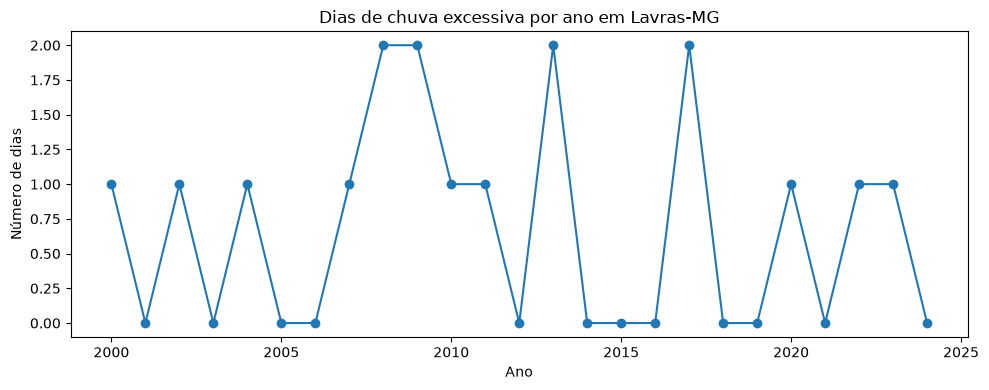

In [2]:
resumo["chuva_excessiva"].plot(marker="o", figsize=(10, 4), title="Dias de chuva excessiva por ano em Lavras-MG")
plt.ylabel("Número de dias")
plt.xlabel("Ano")
plt.tight_layout()
plt.show()

## Achado 3 — Veranico: quando ele ocorre dentro da estação chuvosa

Detectamos 30 veranicos (sequências de ≥10 dias secos consecutivos
dentro da estação chuvosa out-mar) nos 25 anos, com duração média de
14 dias e máxima de 27 dias. O interessante é *quando* eles começam:

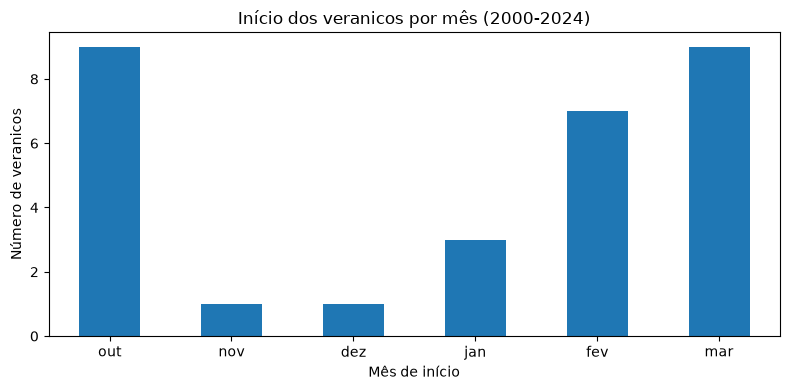

In [3]:
nomes_meses = {10: "out", 11: "nov", 12: "dez", 1: "jan", 2: "fev", 3: "mar"}
inicio_por_mes = veranicos["inicio"].dt.month.value_counts().reindex(nomes_meses.keys(), fill_value=0)
inicio_por_mes.index = inicio_por_mes.index.map(nomes_meses)

inicio_por_mes.plot(kind="bar", figsize=(8, 4), title="Início dos veranicos por mês (2000-2024)")
plt.ylabel("Número de veranicos")
plt.xlabel("Mês de início")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../figuras/veranicos_por_mes.png", dpi=150, bbox_inches="tight")
plt.show()

Os veranicos se concentram em dois momentos: **início da estação
chuvosa (outubro, 9 dos 30)** e **final do verão (fevereiro-março, 16
dos 30)**. Novembro, dezembro e janeiro — o núcleo da estação chuvosa —
concentram só 5 dos 30 veranicos. Esse padrão é um primeiro indício
para a pergunta de pesquisa sobre janelas de menor risco climático
(nov-jan aparenta ser historicamente mais estável), mas com uma
ressalva: 25 anos de dados geram poucos eventos por mês para uma
conclusão estatisticamente forte — é um sinal exploratório, a
confirmar com mais dados ou métodos estatísticos formais.

## Achado 4 — Clima x produção: sem correlação linear forte (ainda)

Cruzamos os índices de risco anuais com a produção do IBGE (Pearson,
n=25 — amostra pequena, resultado exploratório, não causal):

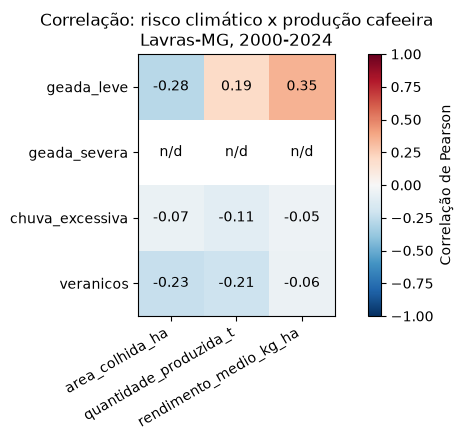

In [4]:
colunas_risco = ["geada_leve", "geada_severa", "chuva_excessiva", "veranicos"]
colunas_producao = ["area_colhida_ha", "quantidade_produzida_t", "rendimento_medio_kg_ha"]

corr_cruzada = clima_x_producao.corr(method="pearson").loc[colunas_risco, colunas_producao]

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(corr_cruzada, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(colunas_producao)), labels=colunas_producao, rotation=30, ha="right")
ax.set_yticks(range(len(colunas_risco)), labels=colunas_risco)

for i in range(len(colunas_risco)):
    for j in range(len(colunas_producao)):
        valor = corr_cruzada.iloc[i, j]
        texto = "n/d" if pd.isna(valor) else f"{valor:.2f}"
        ax.text(j, i, texto, ha="center", va="center", color="black")

ax.set_title("Correlação: risco climático x produção cafeeira\nLavras-MG, 2000-2024")
fig.colorbar(im, ax=ax, label="Correlação de Pearson")
plt.tight_layout()
plt.show()

`geada_leve` aparece agora com as maiores correlações da tabela (área
colhida: -0,28; quantidade produzida: +0,19; rendimento médio: +0,35),
mas isso não é evidência de efeito real: com só 1 ano positivo em 25, a
correlação compara essencialmente um único ano (2000) contra os outros
24. O próprio sinal reforça essa leitura — 2000 teve o **2º maior**
rendimento de toda a série, o oposto do que se esperaria se a geada
estivesse prejudicando a produção. `geada_severa` segue `n/d` (sem
variância — nunca ocorreu nesta estação/período).

Fora a geada, veranico x área colhida (r ≈ -0,23) segue como a
correlação mais confiável, por variar de forma contínua ano a ano.
`area_colhida_ha` cresce quase monotonicamente ao longo dos 25 anos
(expansão econômica da cafeicultura), o que pode gerar correlação
espúria por tendência compartilhada. `rendimento_medio_kg_ha` — a
métrica de produtividade menos afetada por essa expansão — é onde as
demais correlações (fora geada) ficam mais próximas de zero.

**Não encontramos evidência confiável de relação entre risco climático
anual e produtividade do café** com os dados e índices desta fase — o
número mais alto da tabela (geada x rendimento) é estatisticamente
frágil demais para contar como evidência.


## Achado 5 — Defasagem e não linearidade não mudam o quadro

Testamos duas hipóteses que uma correlação simples no mesmo ano pode
não capturar: (1) efeito **defasado** — clima de um ano afetando a
safra do ano seguinte — e (2) efeito **não linear** — anos com muito
veranico se comportando diferente de anos com pouco, mesmo sem
correlação linear forte.

In [5]:
resumo_defasado = resumo.shift(1)
resumo_defasado.columns = [f"{col}_ano_anterior" for col in resumo_defasado.columns]
clima_x_producao_defasada = resumo_defasado.join(producao, how="inner")
colunas_risco_defasado = [f"{col}_ano_anterior" for col in colunas_risco]
corr_defasada = clima_x_producao_defasada.corr(method="pearson").loc[colunas_risco_defasado, colunas_producao]

mediana_veranicos = clima_x_producao["veranicos"].median()
faixa = clima_x_producao["veranicos"].ge(mediana_veranicos).map({
    True: f"muitos veranicos (>= {mediana_veranicos:.0f})",
    False: f"poucos veranicos (< {mediana_veranicos:.0f})",
})
comparacao_faixas = clima_x_producao.groupby(faixa)[colunas_producao].mean()

print("Correlação defasada (risco ano N x produção ano N+1):")
display(corr_defasada)
print("\nProdução média por faixa de veranicos:")
display(comparacao_faixas)

Correlação defasada (risco ano N x produção ano N+1):


,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha
geada_leve_ano_anterior,-0.299072,0.251146,0.444933
geada_severa_ano_anterior,NaN,NaN,NaN
chuva_excessiva_ano_anterior,0.035454,-0.046689,-0.054415
veranicos_ano_anterior,-0.191431,0.066690,0.171315



Produção média por faixa de veranicos:


,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha
veranicos,,,
muitos veranicos (>= 1),4218.388889,5699.722222,1372.888889
poucos veranicos (< 1),4280.000000,5707.714286,1328.571429


A defasagem repete o padrão: `geada_leve_ano_anterior` x rendimento
sobe para r ≈ 0,44 — a maior correlação de toda a análise —, mas pelo
mesmo motivo não é confiável: desloca o único ano de geada (2000) para
explicar 2001, que por coincidência teve o **maior** rendimento de toda
a série. As demais correlações defasadas continuam fracas (|r| < 0,2),
e anos com muitos veranicos vs. poucos têm produção praticamente igual
(rendimento médio ~1.373 vs ~1.329 kg/ha, diferença de ~3%, dentro do
ruído esperado ano a ano).

**Conclusão consolidada**: testamos correlação direta, defasada e
comparação por faixas — em nenhuma abordagem apareceu relação clara e
estatisticamente confiável entre os riscos climáticos medidos e a
produtividade do café em Lavras-MG. A diferença desta rodada é que
geada deixou de ser um problema de *fonte de dado* (resolvido com a
estação 83687 real) e passou a ser um problema de *tamanho de amostra
de eventos extremos* — só 1 geada em 25 anos nesta estação. O
resultado honesto desta fase é que **não conseguimos demonstrar, com
os dados e índices atuais, que clima explica a variação de
produtividade** — mas agora sabemos com mais precisão por quê em cada
variável, o que redireciona a pesquisa para os próximos passos abaixo
em vez de fechar uma resposta definitiva.


## Limitações

- **Geada rara na amostra, não mais subestimada**: resolvemos a
  limitação de fonte usando dado real da estação 83687 (Lavras/UFLA),
  via dados de observação do BR-DWGD (Xavier et al., 2022) — não
  precisamos mais do BDMEP (nunca respondeu ao pedido de exportação)
  nem da API/portal do INMET (bloqueou acesso automatizado). Mas nesses
  25 anos a estação só registrou 1 dia de geada leve e nenhum de geada
  severa — amostra pequena demais para testar o efeito da geada na
  produção, mesmo com dado confiável.
- **Amostra pequena para correlação**: 25 pontos anuais é pouco para
  conclusões estatisticamente robustas sobre clima x produção, mesmo
  testando defasagem e faixas.
- **`area_colhida_ha` tem tendência temporal forte**, não relacionada a
  clima, que pode confundir correlações que a envolvem.
- **Produção é só municipal e anual**: não há dado de produção por
  propriedade/talhão nem em resolução sub-anual, o que impede analisar
  efeito de eventos climáticos específicos (ex. um veranico pontual)
  sobre a safra correspondente.
- **Sem dado de preço/mercado**: variações de produção podem refletir
  fatores econômicos (preço do café, custo de insumos) tanto quanto
  clima — não isolamos esse efeito.

## Próximos passos

- Verificar se a produção do IBGE/SIDRA tem cobertura anterior a 2000
  para Lavras — a estação 83687 tem registro desde 1911, então ampliar
  o recorte temporal poderia trazer mais anos com geada de verdade para
  testar o efeito com mais robustez estatística.
- Se possível, buscar séries de preço do café para controlar o efeito
  de mercado na análise de produção.
- Ampliar o recorte geográfico (outros municípios da região) para
  aumentar o tamanho da amostra.
